In [ ]:
import matplotlib.pyplot as plt
from data import get_data
from indicators import indicators
from strategies import strategy
from backtest import backtest

Equity after trade 0 : 9978.783560982636
Equity after trade 1 : 9929.400657280437
Equity after trade 2 : 9817.402153593397
Equity after trade 3 : 10197.176784044292
Equity after trade 4 : 10178.759894291155


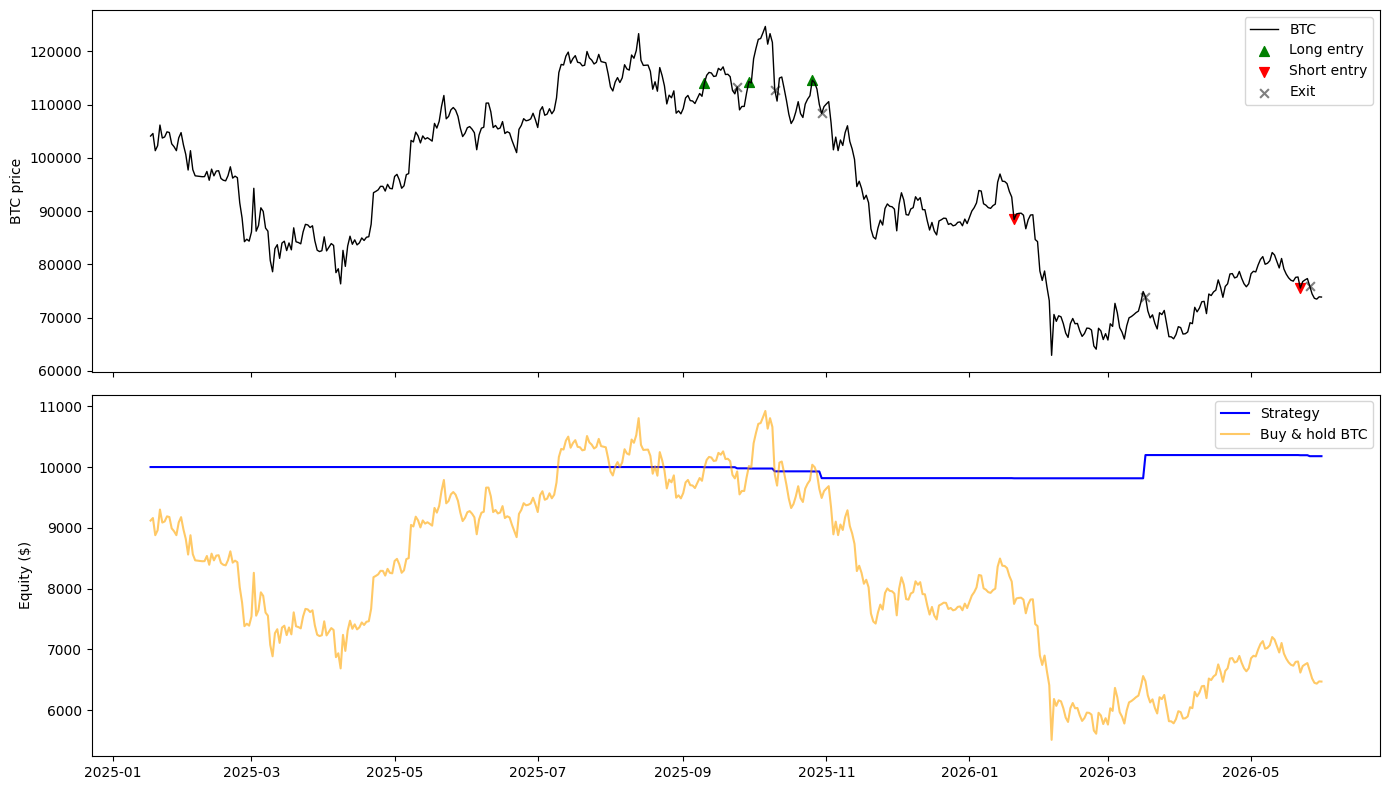

In [3]:
df = get_data()
df = indicators(df)
df = strategy(df)
df, trades = backtest(df)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: BTC price with entry/exit markers
ax1.plot(df["datetime"], df["close"], color="black", linewidth=1, label="BTC")
longs = df[(df["signal"] == 1) & (~df["exit"])]
shorts = df[(df["signal"] == -1) & (~df["exit"])]
exits = df[df["exit"]]
ax1.scatter(longs["datetime"], longs["entry_price"], color="green", marker="^", s=50, label="Long entry")
ax1.scatter(shorts["datetime"], shorts["entry_price"], color="red", marker="v", s=50, label="Short entry")
ax1.scatter(exits["datetime"], exits["close"], color="gray", marker="x", s=40, label="Exit")
ax1.set_ylabel("BTC price")
ax1.legend()

# Bottom: equity curve vs buy-and-hold
buy_and_hold = 10000 * (df["close"] / df["close"].iloc[200])
ax2.plot(df["datetime"], df["equity"], label="Strategy", color="blue")
ax2.plot(df["datetime"], buy_and_hold, label="Buy & hold BTC", color="orange", alpha=0.6)
ax2.set_ylabel("Equity ($)")
ax2.legend()

plt.tight_layout()
plt.show()